In [1]:
# Permite ajustar la anchura de la parte útil de la libreta (reduce los márgenes)
from IPython.core.display import display, HTML
display(HTML("<style>.container{ width:90% }</style>"))

/tmp/ipykernel_1049342/3937453136.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
# !pip install shimmy

In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3

%matplotlib inline
from finrl.config import INDICATORS

import gym
from gym import spaces
import numpy as np
import pandas as pd

from stable_baselines3.common.vec_env import DummyVecEnv

2025-05-19 11:18:27.446635: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 11:18:27.462234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-19 11:18:27.481022: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-19 11:18:27.486590: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-19 11:18:27.500379: I tensorflow/core/platform/cpu_feature_guar

In [4]:
import pickle

with open("train.pkl", "rb") as f:
    train = pickle.load(f)
    
with open("trade.pkl", "rb") as f:
    trade = pickle.load(f)

# train = train.set_index(train.columns[0])
# train.index.names = ['']
# trade = trade.set_index(trade.columns[0])
# trade.index.names = ['']

stock_dimension = len(train.tic.unique()) # tickers únicos sin repetir

state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension

print(f"Number of Indicators: {len(INDICATORS)}")

print(f"Stock Dimension: {stock_dimension}")

print(f"state_space = 1 + 2*{stock_dimension} + ({len(INDICATORS)})*{stock_dimension}")

print(f"State Space: {state_space}")

Number of Indicators: 8
Stock Dimension: 8
state_space = 1 + 2*8 + (8)*8
State Space: 81


### 🌱 Extensión del entorno de trading FinRL a un escenario Multiobjetivo

---

#### 🎯 ¿Qué hicimos?

Adaptamos el entorno de entrenamiento de FinRL para que sea capaz de simular decisiones de inversión **multiobjetivo**, es decir, donde el agente ya no busca únicamente maximizar la ganancia financiera, sino también **minimizar el riesgo** y **promover la sostenibilidad (ESG)**.

---

#### 🧠 ¿Por qué es importante?

En escenarios reales, las decisiones de inversión modernas deben considerar múltiples objetivos simultáneamente:

- **Retorno financiero**: maximizar las ganancias del portafolio.
- **Riesgo**: evitar pérdidas grandes o variabilidad excesiva.
- **Sostenibilidad (ESG)**: favorecer inversiones responsables social y ambientalmente.

Estos objetivos no siempre están alineados. Por ejemplo, un activo muy rentable puede ser riesgoso o tener bajo puntaje ESG. Por eso usamos un enfoque multiobjetivo.

---

#### ⚙️ ¿Qué modificamos?

1. **Se creó un nuevo entorno** llamado `StockTradingMultiEnv`, extendido desde `StockTradingEnv`, con soporte para:
   - Recompensas vectoriales: $$\mathbf{r}_t = [r_1(t), r_2(t), r_3(t)]$$
   - Scalarización lineal: $$r_t = \lambda_1 r_1 + \lambda_2 r_2 + \lambda_3 r_3$$

2. **Definimos cada componente de la recompensa**:
   - $r_1$: cambio en el valor del portafolio (retorno financiero).
   - $r_2$: penalización proporcional a la volatilidad reciente (riesgo).
   - $r_3$: promedio ponderado de los puntajes ESG de los activos en el portafolio.

3. **Usamos un diccionario `ESG_dict`** para asignar a cada activo un puntaje ESG simulado entre 0 y 1.

4. **Implementamos protección automática** contra errores con `defaultdict`, para que cualquier activo no definido reciba un valor ESG por defecto (ej. 0.5).

5. **Entrenamos un agente PPO** sobre este entorno, permitiendo que aprenda políticas influenciadas por las prioridades de inversión definidas mediante los pesos $$\lambda_i$$.

---

#### 🧪 Resultado

Ahora contamos con un entorno de Aprendizaje por Refuerzo capaz de modelar decisiones financieras realistas, considerando **retorno, riesgo y sostenibilidad**. Además, podemos modificar los pesos $\lambda$ para simular distintas preferencias del inversor y observar cómo cambia el comportamiento del agente.

Este avance abre la puerta a experimentos más ricos, como:

- Comparar estrategias con y sin conciencia ESG.
- Evaluar trade-offs entre riesgo y retorno.
- Diseñar políticas que reflejen perfiles de inversionistas sostenibles.

---


In [18]:
class StockTradingMultiEnv(gym.Env):
    """Entorno de trading multiobjetivo con scalarización."""
    metadata = {'render.modes': ['human']}

    def __init__(self,
                 df,
                 stock_dim,
                 hmax,
                 initial_amount, 
                 buy_cost_pct,
                 sell_cost_pct, 
                 reward_scaling,
                 state_space,
                 action_space,
                 tech_indicator_list, 
                 lambda1=1.0,
                 lambda2=0.0,
                 lambda3=0.0,
                 esg_dict=None):
        
        super(StockTradingMultiEnv, self).__init__()
        
        # --- Parámetros del entorno base ---
        self.df = df.reset_index(drop=True)
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.initial_amount = initial_amount
        self.buy_cost_pct = buy_cost_pct
        self.sell_cost_pct = sell_cost_pct
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.tech_indicator_list = tech_indicator_list

        # --- Parámetros adicionales multiobjetivo ---
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.lambda3 = lambda3
        self.esg_dict = esg_dict if esg_dict else {tic: 1.0 for tic in df.tic.unique()}  # default: ESG score = 1

        # --- Espacios de acción y observación ---
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.stock_dim,))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space,))
        
        # --- Estado inicial ---
        self.reset()

    def reset(self):
        self.day = 0
        self.data = self.df.loc[self.df.date == self.df.date.unique()[self.day]]
        self.terminal = False
        self.turbulence = 0
        self.tic_list = self.data.tic.values.tolist()
        self.num_stock_shares = [0] * self.stock_dim
        self.stock_prices = self.data.close.values.tolist()
        self.cash = self.initial_amount
        self.portfolio_value = self.initial_amount
        self.rewards = []
        self.asset_memory = [self.initial_amount]
        self.account_memory = [[0, self.initial_amount]]  # formato: [día, valor del portafolio]
        self.actions_memory = []  # acciones tomadas

        state = self._get_state()
        return np.expand_dims(state, axis=0)  # shape: (1, state_dim) → necesario para SB3


    def _get_state(self):
        self.data = self.df.loc[self.df.date == self.df.date.unique()[self.day]]
        prices = self.data.close.values.tolist()
        indicators = []
        for indicator in self.tech_indicator_list:
            indicators.extend(self.data[indicator].values.tolist())
        state = [self.cash] + self.num_stock_shares + prices + indicators
        return np.array(state)

    def _calculate_rewards(self, prev_value):
        # r1: retorno financiero
        current_value = self._get_portfolio_value()
        r1 = (current_value - prev_value) * self.reward_scaling

        # r2: penalización por riesgo (volatilidad histórica simple)
        if len(self.asset_memory) > 5:
            r2 = -np.std(self.asset_memory[-5:]) / current_value
        else:
            r2 = 0

        # r3: sostenibilidad (ESG score ponderado por portafolio actual)
        weights = np.array(self.num_stock_shares) * np.array(self.stock_prices)
        if weights.sum() > 0:
            norm_weights = weights / weights.sum()
        else:
            norm_weights = np.zeros_like(weights)
        esg_scores = np.array([self.esg_dict[tic] for tic in self.tic_list])
        r3 = np.dot(norm_weights, esg_scores)

        return r1, r2, r3

    def _get_portfolio_value(self):
        return self.cash + np.dot(self.stock_prices, self.num_stock_shares)

    def step(self, actions):
        self.terminal = self.day >= len(self.df.date.unique()) - 1
        if self.terminal:
            return self._get_state(), 0, self.terminal, {}

        prev_value = self._get_portfolio_value()
        actions = (actions * self.hmax).astype(int)
        self.stock_prices = self.data.close.values.tolist()

        for i in range(self.stock_dim):
            if actions[i] > 0:
                buy_amount = min(self.cash // self.stock_prices[i], actions[i])
                #if buy_amount > 0:
                    #print(f"Día {self.day} - Comprando {buy_amount} de {self.tic_list[i]} a ${self.stock_prices[i]:.2f}")
                cost = self.stock_prices[i] * buy_amount * (1 + self.buy_cost_pct[i])
                self.cash -= cost
                self.num_stock_shares[i] += buy_amount

            elif actions[i] < 0:
                sell_amount = min(self.num_stock_shares[i], -actions[i])
                #if sell_amount > 0:
                    #print(f"Día {self.day} - Vendiendo {sell_amount} de {self.tic_list[i]} a ${self.stock_prices[i]:.2f}")
                gain = self.stock_prices[i] * sell_amount * (1 - self.sell_cost_pct[i])
                self.cash += gain
                self.num_stock_shares[i] -= sell_amount

        self.day += 1
        self.data = self.df.loc[self.df.date == self.df.date.unique()[self.day]]
        self.stock_prices = self.data.close.values.tolist()

        new_value = self._get_portfolio_value()
        self.asset_memory.append(new_value)

        r1, r2, r3 = self._calculate_rewards(prev_value)
        reward = self.lambda1 * r1 + self.lambda2 * r2 + self.lambda3 * r3

        # Guardar valor del portafolio con el día actual
        self.account_memory.append([self.day, new_value])
        self.portfolio_value = new_value  # 🔧 Aquí se actualiza el valor actual del portafolio

        # Guardar las acciones tomadas
        self.actions_memory.append(actions)

        return self._get_state(), reward, self.terminal, {"r1": r1, "r2": r2, "r3": r3}


    
    def get_sb_env():
        env = DummyVecEnvWithMemory([lambda: env_instance], env_instance)
        obs = env.reset()  # Aquí obs debe tener shape (1, state_dim)
        return env, obs

    
    def save_asset_memory(self):
        return pd.DataFrame(self.account_memory, columns=["date", "account_value"])

    def save_action_memory(self):
        return pd.DataFrame(self.actions_memory)
    

    
from stable_baselines3.common.vec_env import DummyVecEnv


# Clase personalizada que permite exponer las funciones de memoria desde DummyVecEnv
class DummyVecEnvWithMemory(DummyVecEnv):
    def __init__(self, env_fns, original_env):
        super().__init__(env_fns)
        self.original_env = original_env

    def save_asset_memory(self):
        return self.original_env.save_asset_memory()

    def save_action_memory(self):
        return self.original_env.save_action_memory()

    def patch_get_sb_env(env_instance):
        def get_sb_env():
            env = DummyVecEnvWithMemory([lambda: env_instance], env_instance)
            obs = env.reset()
            return env, obs  # obs debe tener shape (1, state_dim)
        env_instance.get_sb_env = get_sb_env

### 🎯 Indicador ESG utilizado

Para incorporar sostenibilidad en el proceso de decisión del agente, se adopta el enfoque planteado en el artículo:

> *“A Hierarchical Approach to a Tri-Objective Portfolio Optimization Problem Considering an ESG Index” (Mathematics, 2024)*

Este trabajo utiliza el **ESG Risk Score de Sustainalytics**, una métrica ampliamente aceptada que cuantifica el riesgo relacionado con factores ambientales, sociales y de gobernanza. En particular:

- El score ESG mide el nivel de exposición de una empresa a riesgos ESG materiales.
- Se expresa en una escala donde **valores bajos indican menor riesgo ESG** (mejor desempeño).
- Puede adaptarse como una utilidad directa o invertida para su uso como recompensa.

Dado que en FinRL no se tiene acceso directo a ESG reales en todos los activos, en este proyecto:

- Se utiliza una **versión simulada** del score ESG, consistente con el enfoque del artículo.
- A cada activo se le asigna un valor continuo entre 0 y 1 que representa su score ESG relativo.
- Este valor se utiliza en el entorno como **componente de recompensa** junto con retorno y riesgo, formando una recompensa vectorial escalarizada:

$$
r_t = \lambda_1 \cdot r_{\text{retorno}} + \lambda_2 \cdot r_{\text{riesgo}} + \lambda_3 \cdot r_{\text{ESG}}
$$

En fases posteriores, puede integrarse un score real a partir de fuentes públicas como Yahoo Finance, MSCI o Sustainalytics si se dispone de acceso.


Stock Dimension: 8
State Space: 81
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/danirm/anaconda3/envs/proyecto_RL/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


----------------------------------
| time/              |           |
|    fps             | 128       |
|    iterations      | 1         |
|    time_elapsed    | 15        |
|    total_timesteps | 2048      |
| train/             |           |
|    reward          | 2.1298995 |
----------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.89e+03   |
|    ep_rew_mean          | 4.18e+03   |
| time/                   |            |
|    fps                  | 125        |
|    iterations           | 2          |
|    time_elapsed         | 32         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.00918261 |
|    clip_fraction        | 0.122      |
|    clip_range           | 0.2        |
|    entropy_loss         | -11.4      |
|    explained_variance   | -0.00482   |
|    learning_rate        | 0.00025    |
|    loss                 | 1

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.89e+03    |
|    ep_rew_mean          | 4.37e+03    |
| time/                   |             |
|    fps                  | 120         |
|    iterations           | 11          |
|    time_elapsed         | 186         |
|    total_timesteps      | 22528       |
| train/                  |             |
|    approx_kl            | 0.010498794 |
|    clip_fraction        | 0.15        |
|    clip_range           | 0.2         |
|    entropy_loss         | -11.4       |
|    explained_variance   | -0.000134   |
|    learning_rate        | 0.00025     |
|    loss                 | 151         |
|    n_updates            | 100         |
|    policy_gradient_loss | -0.0118     |
|    reward               | -3.8773444  |
|    std                  | 1.01        |
|    value_loss           | 246         |
-----------------------------------------
----------------------------------

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.89e+03    |
|    ep_rew_mean          | 4.45e+03    |
| time/                   |             |
|    fps                  | 121         |
|    iterations           | 20          |
|    time_elapsed         | 337         |
|    total_timesteps      | 40960       |
| train/                  |             |
|    approx_kl            | 0.012419073 |
|    clip_fraction        | 0.109       |
|    clip_range           | 0.2         |
|    entropy_loss         | -11.8       |
|    explained_variance   | 0.00276     |
|    learning_rate        | 0.00025     |
|    loss                 | 31.9        |
|    n_updates            | 190         |
|    policy_gradient_loss | -0.00682    |
|    reward               | 1.2059511   |
|    std                  | 1.05        |
|    value_loss           | 162         |
-----------------------------------------
----------------------------------

/tmp/ipykernel_1049342/3692283143.py:117: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result_multi = pd.merge(result_multi, dji, how='outer', left_index=True, right_index=True).fillna(method='bfill')


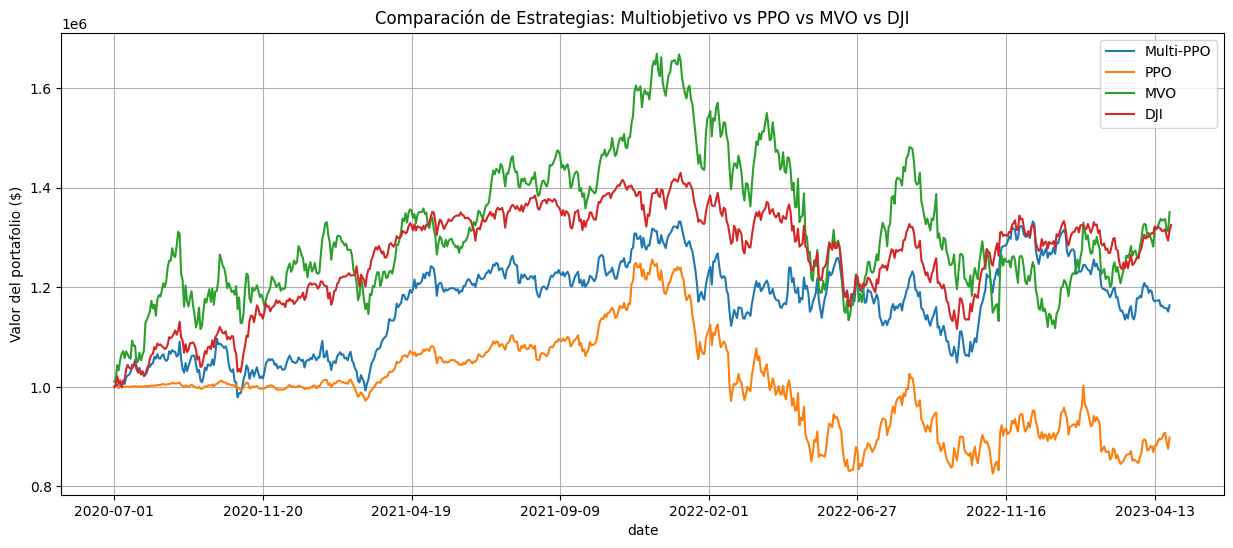

In [21]:
import pickle
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt



# === 1. Cargar datos ===
with open("train.pkl", "rb") as f:
    train = pickle.load(f)

with open("trade.pkl", "rb") as f:
    trade = pickle.load(f)

# === 2. Definir indicadores y dimensiones ===
#INDICATORS = ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence']
stock_dimension = len(train.tic.unique())
state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension

print(f"Stock Dimension: {stock_dimension}")
print(f"State Space: {state_space}")


# === 3. Scalarización y ESG ===
lambda1 = 1.0
lambda2 = 0.5
lambda3 = 2.0

ESG_dict = defaultdict(lambda: 0.5, {
    'aapl': 0.9, 'amzn': 0.7, 'cat': 0.6, 'hd': 0.5,
    'ibm': 0.8, 'jpm': 0.4, 'mcd': 0.3, 'wmt': 0.9
})


# === 4. Definir entorno multiobjetivo ===
env_kwargs_multi = {
    "hmax": 1000,
    "initial_amount": 1_000_000,
    "buy_cost_pct": [0.001] * stock_dimension,
    "sell_cost_pct": [0.001] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "lambda1": lambda1,
    "lambda2": lambda2,
    "lambda3": lambda3,
    "esg_dict": ESG_dict
}


# === 5. Entrenar agente PPO multiobjetivo ===
e_train_multi = StockTradingMultiEnv(df=train, **env_kwargs_multi)

agent_multi = DRLAgent(env=e_train_multi)

model_ppo_multi = agent_multi.get_model("ppo")

trained_ppo_multi = agent_multi.train_model(
    model=model_ppo_multi,
    tb_log_name='ppo_multi',
    total_timesteps=50000
)


# === 6. Evaluación manual en el conjunto de prueba ===
env = DummyVecEnv([lambda: StockTradingMultiEnv(df=trade, **env_kwargs_multi)])
obs = env.reset()

account_values = []
actions_taken = []

for i in range(len(trade.date.unique()) - 1):
    action, _ = trained_ppo_multi.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

    raw_env = env.envs[0]
    account_values.append(raw_env.portfolio_value)
    actions_taken.append(action[0])

    # 🚨 Diagnóstico de acciones y recompensas
#     print(f"Paso {i}:")
#     print(f"  Acción tomada: {action[0]}")
#     print(f"  Valor del portafolio: {raw_env.portfolio_value}")
#     print(f"  Recompensa total: {reward}")
#     print(f"  Recompensas individuales: r1={info[0]['r1']:.5f}, r2={info[0]['r2']:.5f}, r3={info[0]['r3']:.5f}")
#     print("-" * 50)

    if done:
        print("Fin del entorno")
        break

df_account_value_multi = pd.DataFrame(account_values, columns=["account_value"])
df_actions_multi = pd.DataFrame(actions_taken, columns=[f"a{i}" for i in range(raw_env.stock_dim)])

df_result_multi = df_account_value_multi.copy()
df_result_multi["date"] = trade.date.unique()[1:]  # omite primer día
df_result_multi = df_result_multi.set_index("date")
df_result_multi.columns = ['Multi-PPO']


# === 7. Cargar resultados previos PPO, MVO y DJI ===
with open("df_result_ppo.pkl", "rb") as f:
    df_result_ppo = pickle.load(f)

with open("MVO_result.pkl", "rb") as f:
    MVO_result = pickle.load(f)

with open("dji.pkl", "rb") as f:
    dji = pickle.load(f)

# === 8. Unificar y graficar ===
result_multi = pd.merge(df_result_multi, df_result_ppo, how='outer', left_index=True, right_index=True)
result_multi = pd.merge(result_multi, MVO_result, how='outer', left_index=True, right_index=True)
result_multi = pd.merge(result_multi, dji, how='outer', left_index=True, right_index=True).fillna(method='bfill')
result_multi.columns = ['Multi-PPO', 'PPO', 'MVO', 'DJI']

plt.rcParams["figure.figsize"] = (15, 6)
result_multi.plot(title="Comparación de Estrategias: Multiobjetivo vs PPO vs MVO vs DJI")
plt.ylabel("Valor del portafolio ($)")
plt.grid(True)
plt.show()

In [22]:
import yfinance as yf

data = yf.download("AAPL", start="2025-05-15", end="2025-05-21")
print(data.tail())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-05-15  211.449997  212.960007  209.539993  210.949997  45029500
2025-05-16  211.259995  212.570007  209.770004  212.360001  54737900
2025-05-19  208.779999  209.479996  204.259995  207.910004  46140500
2025-05-20  206.860001  208.470001  205.029999  207.669998  42443700


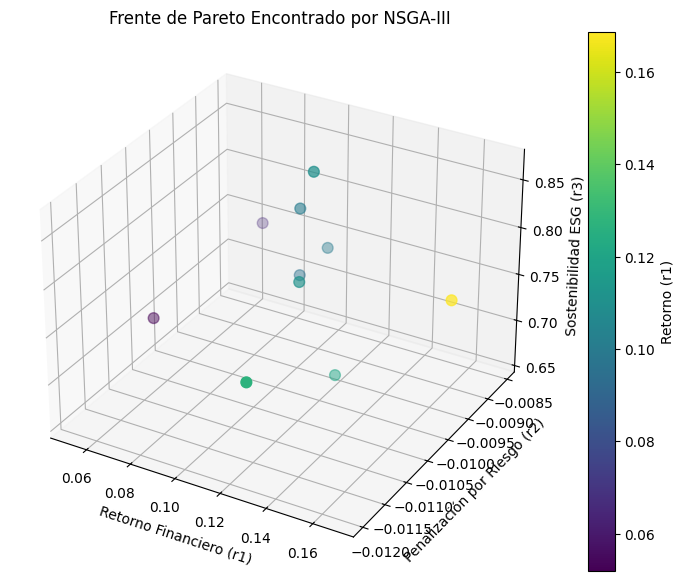

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cargar el CSV generado por NSGA-III
df = pd.read_csv("resultados_nsga3.csv")

# Extraer las columnas de los tres objetivos
r1 = df["r1"]  # retorno financiero promedio
r2 = df["r2"]  # penalización por riesgo promedio
r3 = df["r3"]  # ESG promedio

# Crear la figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos
sc = ax.scatter(r1, r2, r3, c=r1, cmap='viridis', s=60)

# Etiquetas y título
ax.set_xlabel("Retorno Financiero (r1)")
ax.set_ylabel("Penalización por Riesgo (r2)")
ax.set_zlabel("Sostenibilidad ESG (r3)")
plt.title("Frente de Pareto Encontrado por NSGA-III")

# Colorbar opcional
plt.colorbar(sc, label="Retorno (r1)")

plt.show()